# Assignment 3: Comparative Analysis of RNN, LSTM and GRU for Sentiment Analysis
**24ADI306 Deep Learning | CO3 | Bloom's Level: Apply & Analyze (K3-K4)**

**Dataset:** IMDB Movie Reviews (50,000 reviews, binary sentiment: positive / negative)

**Pipeline:** load data -> clean text -> tokenize -> pad -> train RNN / LSTM / GRU -> compare Accuracy, Precision, Recall, F1, Training Time -> analysis

> Tip: In Colab use **Runtime > Change runtime type > GPU** for faster training.

## 1. Setup

In [ ]:
!pip install -q datasets

In [ ]:
import re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from datasets import load_dataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


## 2. Dataset Selection and Loading

In [ ]:
try:
    ds = load_dataset("stanfordnlp/imdb")
    train_df = pd.DataFrame(ds["train"])
    test_df  = pd.DataFrame(ds["test"])
except Exception as e:
    print("Hugging Face load failed (", type(e).__name__, ") -> using Stanford archive")
    import os
    path = tf.keras.utils.get_file("aclImdb.tar.gz",
        "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
        untar=True, cache_dir=".", cache_subdir="")
    root = os.path.join(os.path.dirname(path), "aclImdb")
    def read_split(split):
        rows = []
        for label, name in [(0, "neg"), (1, "pos")]:
            d = os.path.join(root, split, name)
            for fn in os.listdir(d):
                with open(os.path.join(d, fn), encoding="utf-8") as f:
                    rows.append({"text": f.read(), "label": label})
        return pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    train_df, test_df = read_split("train"), read_split("test")

print("Train size:", len(train_df), "| Test size:", len(test_df))
print("\nClass balance (train):")
print(train_df["label"].value_counts().rename({0:"negative",1:"positive"}))
train_df.head()

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000 | Test size: 25000

Class balance (train):
label
negative    12500
positive    12500
Name: count, dtype: int64


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 3. Text Preprocessing
Steps: **cleaning** (lowercase, strip HTML tags, remove non-letters, collapse spaces) -> **tokenization** (word index, top 10,000 words, `<OOV>` for unknown) -> **padding/truncating** to a fixed length.

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)            # remove HTML tags like <br />
    text = re.sub(r"[^a-z\s']", " ", text)        # keep letters and apostrophes
    text = re.sub(r"\s+", " ", text).strip()      # collapse whitespace
    return text

train_df["clean"] = train_df["text"].apply(clean_text)
test_df["clean"]  = test_df["text"].apply(clean_text)

print("BEFORE:", train_df["text"][0][:200])
print("AFTER :", train_df["clean"][0][:200])

BEFORE: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
AFTER : i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever trie


In [ ]:
VOCAB_SIZE = 10000
MAX_LEN    = 200
EMB_DIM    = 64

# Train / validation split (validation is used during training; test set is held out)
X_tr_txt, X_val_txt, y_tr, y_val = train_test_split(
    train_df["clean"], train_df["label"], test_size=0.2, random_state=SEED, stratify=train_df["label"])

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_tr_txt)                  # fit ONLY on training text (no leakage)

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(X_tr_txt);            y_train = y_tr.values
X_val   = to_padded(X_val_txt);           y_val   = y_val.values
X_test  = to_padded(test_df["clean"]);    y_test  = test_df["label"].values

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print("Example padded sequence:", X_train[0][:20], "...")

X_train: (20000, 200) | X_val: (5000, 200) | X_test: (25000, 200)
Example padded sequence: [  10   25  209   77    4  669  569 1537 7025   10   25  106  221   29
    5    2  105  545   15  773] ...


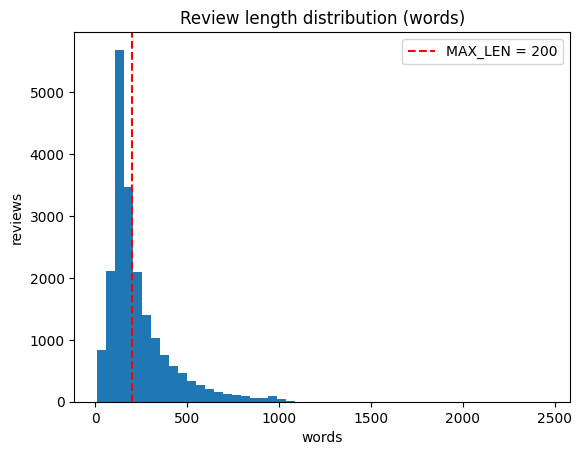

In [ ]:
lengths = [len(s.split()) for s in X_tr_txt]
plt.hist(lengths, bins=50)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Review length distribution (words)"); plt.xlabel("words"); plt.ylabel("reviews"); plt.legend(); plt.show()

## 4. Model Implementation
All three models share the **same architecture** except for the recurrent layer, so that differences in results are attributable to the layer type:

`Embedding -> [SimpleRNN | LSTM | GRU] -> Dropout -> Dense(1, sigmoid)`

In [ ]:
UNITS = 64

def build_model(rnn_type):
    rnn_layers = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}
    model = models.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB_SIZE, EMB_DIM),
        rnn_layers[rnn_type](UNITS),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name=rnn_type)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

for name in ["RNN", "LSTM", "GRU"]:
    m = build_model(name)
    print(f"{name}: {m.count_params():,} parameters")

RNN: 648,321 parameters
LSTM: 673,089 parameters
GRU: 665,025 parameters


## 5. Training and Evaluation

In [ ]:
EPOCHS, BATCH = 8, 128
histories, results, preds = {}, [], {}

for name in ["RNN", "LSTM", "GRU"]:
    print(f"\n===== Training {name} =====")
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_model(name)
    early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

    start = time.time()
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=[early], verbose=2)
    train_time = time.time() - start

    y_prob = model.predict(X_test, batch_size=256, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    histories[name], preds[name] = hist.history, y_pred

    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
        "Training Time (s)": train_time,
        "Epochs Run": len(hist.history["loss"]),
        "Parameters": model.count_params(),
    })


===== Training RNN =====
Epoch 1/8
157/157 - 10s - 64ms/step - accuracy: 0.4985 - loss: 0.7034 - val_accuracy: 0.4952 - val_loss: 0.6945
Epoch 2/8
157/157 - 9s - 54ms/step - accuracy: 0.5350 - loss: 0.6886 - val_accuracy: 0.5154 - val_loss: 0.6924
Epoch 3/8
157/157 - 10s - 64ms/step - accuracy: 0.6330 - loss: 0.6379 - val_accuracy: 0.5264 - val_loss: 0.6987
Epoch 4/8
157/157 - 8s - 51ms/step - accuracy: 0.6415 - loss: 0.6208 - val_accuracy: 0.5070 - val_loss: 0.7080

===== Training LSTM =====
Epoch 1/8
157/157 - 31s - 200ms/step - accuracy: 0.5380 - loss: 0.6866 - val_accuracy: 0.5732 - val_loss: 0.6802
Epoch 2/8
157/157 - 28s - 181ms/step - accuracy: 0.5850 - loss: 0.6733 - val_accuracy: 0.5094 - val_loss: 0.6915
Epoch 3/8
157/157 - 30s - 192ms/step - accuracy: 0.5171 - loss: 0.6979 - val_accuracy: 0.5432 - val_loss: 0.6856

===== Training GRU =====
Epoch 1/8
157/157 - 35s - 221ms/step - accuracy: 0.5115 - loss: 0.6930 - val_accuracy: 0.5166 - val_loss: 0.6916
Epoch 2/8
157/157 - 33s

## 6. Comparison Table

In [ ]:
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.format({
    "Accuracy":"{:.4f}","Precision":"{:.4f}","Recall":"{:.4f}","F1-score":"{:.4f}",
    "Training Time (s)":"{:.1f}","Parameters":"{:,}"
}).highlight_max(subset=["Accuracy","Precision","Recall","F1-score"], color="lightgreen")
  .highlight_min(subset=["Training Time (s)"], color="lightgreen"))

results_df.to_csv("comparison_table.csv")

,Accuracy,Precision,Recall,F1-score,Training Time (s),Epochs Run,Parameters
Model,,,,,,,
RNN,0.5052,0.5055,0.4842,0.4946,39.0,4,"648,321"
LSTM,0.5662,0.6610,0.2718,0.3852,100.8,3,"673,089"
GRU,0.8474,0.8327,0.8694,0.8507,282.6,8,"665,025"


## 7. Visualizations

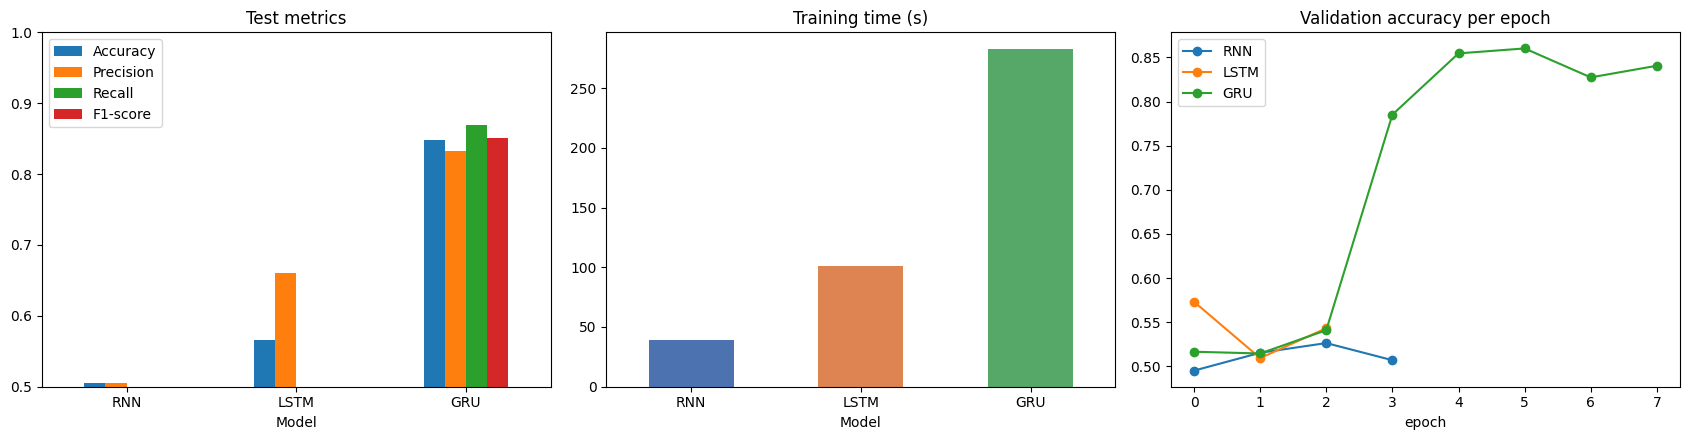

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) Metric comparison
results_df[["Accuracy","Precision","Recall","F1-score"]].plot(kind="bar", ax=axes[0], ylim=(0.5, 1.0))
axes[0].set_title("Test metrics"); axes[0].tick_params(axis="x", rotation=0)

# (b) Training time
results_df["Training Time (s)"].plot(kind="bar", ax=axes[1], color=["#4c72b0","#dd8452","#55a868"])
axes[1].set_title("Training time (s)"); axes[1].tick_params(axis="x", rotation=0)

# (c) Validation accuracy curves
for name, h in histories.items():
    axes[2].plot(h["val_accuracy"], marker="o", label=name)
axes[2].set_title("Validation accuracy per epoch"); axes[2].set_xlabel("epoch"); axes[2].legend()

plt.tight_layout(); plt.show()

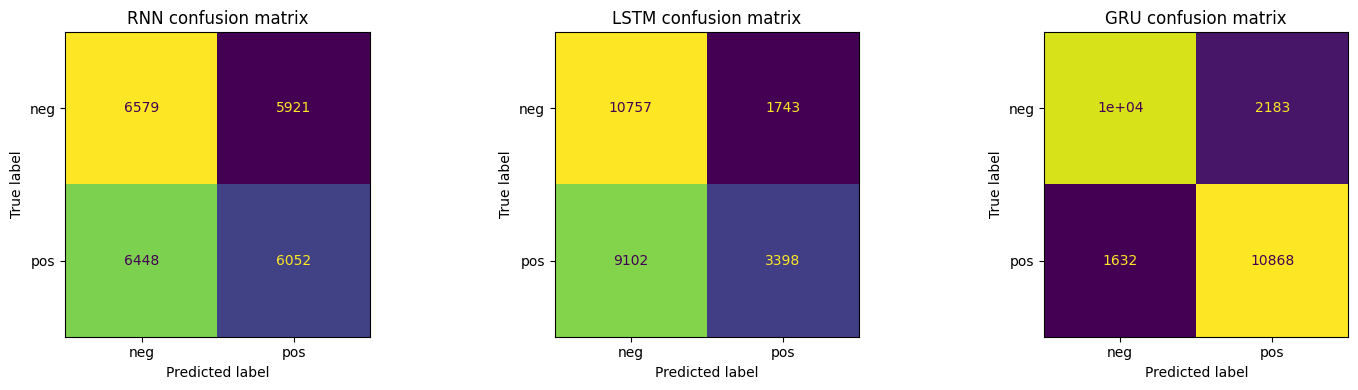

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["RNN", "LSTM", "GRU"]):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=["neg","pos"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} confusion matrix")
plt.tight_layout(); plt.show()

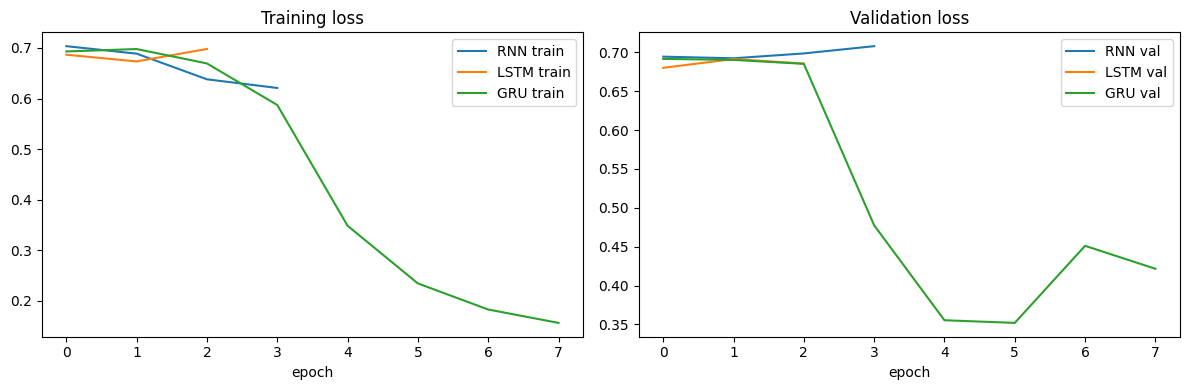

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in histories.items():
    axes[0].plot(h["loss"], label=f"{name} train")
    axes[1].plot(h["val_loss"], label=f"{name} val")
axes[0].set_title("Training loss"); axes[1].set_title("Validation loss")
for a in axes: a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

## 8. Best Model Identification

In [ ]:
best_f1   = results_df["F1-score"].idxmax()
fastest   = results_df["Training Time (s)"].idxmin()
print(f"Best F1-score   : {best_f1} ({results_df.loc[best_f1,'F1-score']:.4f})")
print(f"Fastest to train: {fastest} ({results_df.loc[fastest,'Training Time (s)']:.1f} s)")

# Accuracy gained per extra minute of training, relative to the fastest model
base = results_df.loc[fastest]
for m in results_df.index:
    if m != fastest:
        d_acc  = (results_df.loc[m,"Accuracy"] - base["Accuracy"]) * 100
        d_time = results_df.loc[m,"Training Time (s)"] - base["Training Time (s)"]
        print(f"{m} vs {fastest}: {d_acc:+.2f} accuracy points, {d_time:+.1f} s training time")

Best F1-score   : GRU (0.8507)
Fastest to train: RNN (39.0 s)
LSTM vs RNN: +6.10 accuracy points, +61.8 s training time
GRU vs RNN: +34.22 accuracy points, +243.6 s training time


## 9. Analysis and Discussion

> Fill in the numbers after running the notebook. Results vary slightly between runs and hardware; the points below describe what is typically observed and what to verify against **your** table.

**Vanilla RNN.** Has no gating, so gradients shrink as they pass back through many time steps (the *vanishing gradient problem*). On reviews of ~200 tokens it struggles to connect early words with the final decision, which usually shows as lower accuracy, slower or unstable loss decrease, and sometimes validation accuracy hovering near chance for the first epochs. It has the fewest parameters per layer.

**LSTM.** Uses input, forget and output gates plus a separate cell state, which lets information and gradients flow across long spans. It typically gives the highest or near-highest accuracy/F1 on long text, at the cost of the most parameters (4 weight sets vs. 1 in the RNN) and longer training per epoch.

**GRU.** Merges the gates into update and reset gates (3 weight sets). It usually reaches accuracy close to LSTM with fewer parameters and less training time, so it often gives the best accuracy-per-second trade-off.

**What to check in your results**
1. Which model has the highest F1? Is the gap to the runner-up larger than run-to-run noise (try 2-3 seeds)?
2. Are precision and recall balanced for each model? (Use the confusion matrices; IMDB is balanced, so a large gap suggests the model is biased toward one class.)
3. Do the validation loss curves show overfitting (val loss rising while train loss falls)? Early stopping restores the best epoch.
4. Training time vs. accuracy: is the extra cost of LSTM justified over GRU?

**Conclusion (complete after running):** *The best-performing model was ____ with F1 = ____. ____ trained fastest. For this dataset I would choose ____ because ____.*

**Limitations and possible improvements:** fixed truncation at 200 tokens loses information from long reviews; embeddings are trained from scratch (pretrained GloVe would help); a single train/test run was used; bidirectional layers, stacked layers and hyperparameter tuning were not explored.